#### Assignment 3-Reinforcement Learning (DSCI 6650)
#### Name: Hashna Binte Nahar
#### ID:202290355

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

##### Set the Grid world then decide the parameter. After that set environment. Then use Use the Sarsa and Q-learning algorithms to learn the optimal policy. Here we assume to use ϵ-greedy action selection for this task.


SARSA Policy:
   0  1  2  3  4
0  T  ←  ←  →  T
1  ↑  ↑  ↑  ↑  ↑
2  R  R  ↑  R  R
3  ↓  →  ↑  ←  ←
4  S  ↑  ↑  ←  ↑

Q-learning Policy:
   0  1  2  3  4
0  T  ←  ←  →  T
1  ↑  ↑  ↑  ↑  ↑
2  R  R  ↑  R  R
3  →  →  ↑  ←  ←
4  S  ↑  ↑  ↑  →


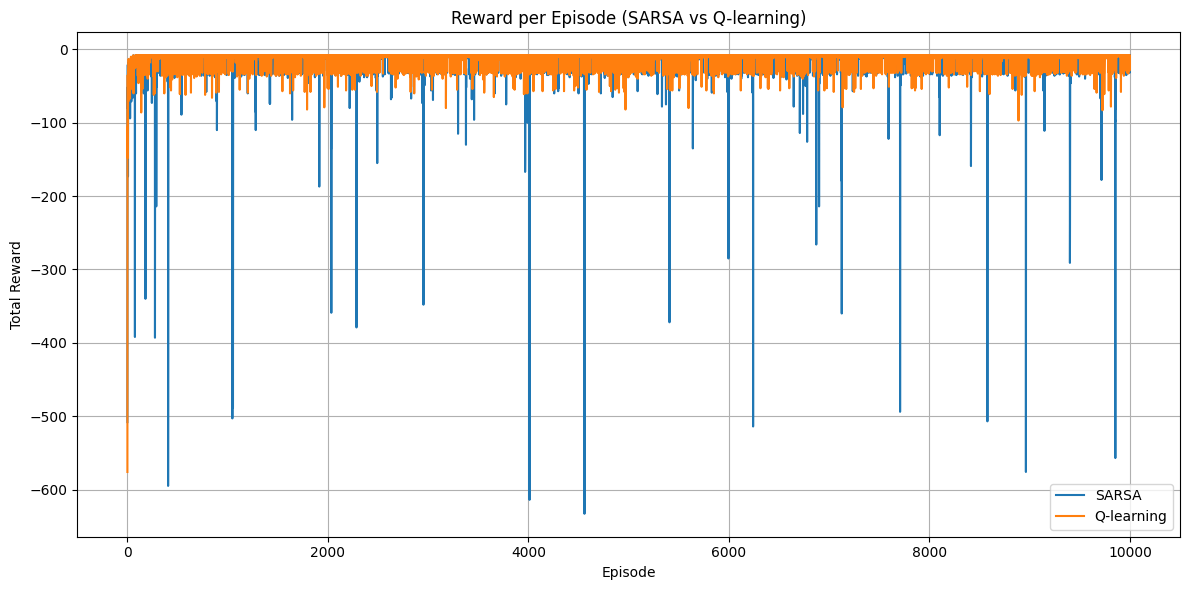

In [3]:
# -------------------
# GridWorld Setup
# -------------------
GRID_SIZE = 5
START_STATE = (4, 0)   # Bottom-left corner (row 4, column 0)
RED_STATES = [(2, 0), (2, 1), (2, 3), (2, 4)]  # A "wall" of penalty states (row 2, some columns)
TERMINAL_STATES = [(0, 0), (0, 4)]  # Top-left and top-right corners
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
ACTION_SYMBOLS = ['↑', '↓', '←', '→']

# -------------------
# Hyperparameters
# -------------------
ALPHA = 0.1
GAMMA = 0.95
EPSILON = 0.1
EPISODES = 10000
MAX_STEPS = 500

# -------------------
# Environment Functions
# -------------------
def is_valid(state):
    x, y = state
    return 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE

def step(state, action):
    if state in TERMINAL_STATES:
        return state, 0, True
    next_state = (state[0] + action[0], state[1] + action[1])
    if not is_valid(next_state):
        return state, -1, False
    if next_state in RED_STATES:
        return START_STATE, -20, False
    if next_state in TERMINAL_STATES:
        return next_state, -1, True
    return next_state, -1, False

# -------------------
# Helper Functions
# -------------------
def epsilon_greedy(Q, state):
    if np.random.rand() < EPSILON:
        return random.randint(0, 3)
    return np.argmax(Q[state])

def init_q_table():
    return {(i, j): np.zeros(4) for i in range(GRID_SIZE) for j in range(GRID_SIZE)}

# -------------------
# SARSA Algorithm
# -------------------
def sarsa():
    Q = init_q_table()
    rewards = []
    for ep in range(EPISODES):
        state = START_STATE
        action = epsilon_greedy(Q, state)
        total_reward = 0
        for _ in range(MAX_STEPS):
            next_state, reward, done = step(state, ACTIONS[action])
            next_action = epsilon_greedy(Q, next_state)
            Q[state][action] += ALPHA * (reward + GAMMA * Q[next_state][next_action] - Q[state][action])
            state, action = next_state, next_action
            total_reward += reward
            if done:
                break
        rewards.append(total_reward)
    return Q, rewards

# -------------------
# Q-Learning Algorithm
# -------------------
def q_learning():
    Q = init_q_table()
    rewards = []
    for ep in range(EPISODES):
        state = START_STATE
        total_reward = 0
        for _ in range(MAX_STEPS):
            action = epsilon_greedy(Q, state)
            next_state, reward, done = step(state, ACTIONS[action])
            Q[state][action] += ALPHA * (reward + GAMMA * np.max(Q[next_state]) - Q[state][action])
            state = next_state
            total_reward += reward
            if done:
                break
        rewards.append(total_reward)
    return Q, rewards

# -------------------
# Extract Policy
# -------------------
def extract_policy(Q):
    policy = np.full((GRID_SIZE, GRID_SIZE), ' ')
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            if state == START_STATE:
                policy[i][j] = 'S'
            elif state in RED_STATES:
                policy[i][j] = 'R'
            elif state in TERMINAL_STATES:
                policy[i][j] = 'T'
            else:
                policy[i][j] = ACTION_SYMBOLS[np.argmax(Q[state])]
    return policy

# -------------------
# Main Execution
# -------------------
Q_sarsa, rewards_sarsa = sarsa()
Q_qlearn, rewards_qlearn = q_learning()

policy_sarsa = extract_policy(Q_sarsa)
policy_qlearn = extract_policy(Q_qlearn)

print("\nSARSA Policy:")
print(pd.DataFrame(policy_sarsa))
print("\nQ-learning Policy:")
print(pd.DataFrame(policy_qlearn))

# -------------------
# Reward Curves
# -------------------
plt.figure(figsize=(12, 6))
plt.plot(rewards_sarsa, label='SARSA')
plt.plot(rewards_qlearn, label='Q-learning')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward per Episode (SARSA vs Q-learning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


##### Comment:
##### Here for SARSA Policy the agent tends to avoid red states (R) by taking safer upward or leftward paths. SARSA learns cautiously because it evaluates based on the policy it actually follows (on-policy). In this case, SARSA avoids going through (2,2) even though it is a safe gap — instead, it prefers a longer but safer route.
##### Q-Learning Policy exploits the gap at (2,2) by moving straight upward into the terminal. This shows Q-learning learns a more optimal path through trial and error, even if it risks hitting red squares initially. Q-learning is off-policy, so it updates toward the best possible future (greedy), regardless of the current action taken.
##### Reward Curves:
##### Q-learning (Orange Line): More stable and less noisy.Rewards improve quickly and stabilize near optimal values (closer to −5 to −10 range).Q-learning learns the shortest path faster and sticks to it.
##### SARSA (Blue Line):More fluctuation and occasional large negative spikes (e.g., −600). This indicates that SARSA sometimes keeps hitting red states due to exploration, which resets the agent repeatedly. SARSA is more cautious, and its learning curve is noisier, especially under epsilon-greedy exploration.

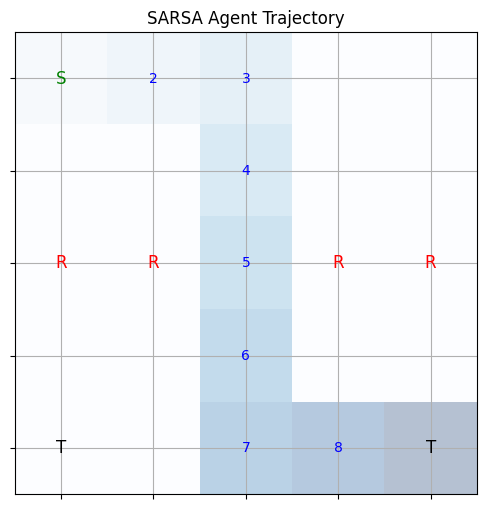

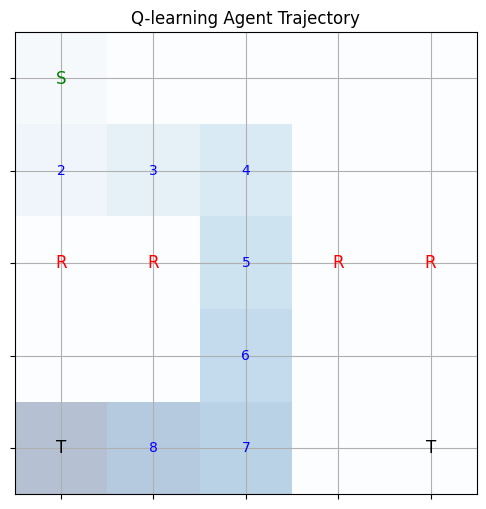

In [5]:
# -------------------
# Simulate a Trajectory
# -------------------
def simulate_trajectory(Q, max_steps=100):
    state = START_STATE
    trajectory = [state]

    for _ in range(max_steps):
        if state in TERMINAL_STATES:
            break
        action = np.argmax(Q[state])
        next_state, _, done = step(state, ACTIONS[action])
        trajectory.append(next_state)
        if done:
            break
        state = next_state
    return trajectory

# -------------------
# Plot the Trajectory
# -------------------
def plot_trajectory(trajectory, title):
    grid = np.zeros((GRID_SIZE, GRID_SIZE))
    for idx, (x, y) in enumerate(trajectory):
        grid[x][y] = idx + 1

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(grid, cmap='Blues', alpha=0.3)

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            if (i, j) in TERMINAL_STATES:
                ax.text(j, i, 'T', ha='center', va='center', fontsize=12, color='black')
            elif (i, j) in RED_STATES:
                ax.text(j, i, 'R', ha='center', va='center', fontsize=12, color='red')
            elif (i, j) == START_STATE:
                ax.text(j, i, 'S', ha='center', va='center', fontsize=12, color='green')
            elif (i, j) in trajectory:
                step_num = trajectory.index((i, j)) + 1
                ax.text(j, i, f'{step_num}', ha='center', va='center', fontsize=10, color='blue')

    ax.set_xticks(np.arange(GRID_SIZE))
    ax.set_yticks(np.arange(GRID_SIZE))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title)
    ax.grid(True)
    plt.gca().invert_yaxis()
    plt.show()

# -------------------
# Run Everything
# -------------------
Q_sarsa, _ = sarsa()
Q_qlearn, _ = q_learning()

trajectory_sarsa = simulate_trajectory(Q_sarsa)
trajectory_qlearn = simulate_trajectory(Q_qlearn)

plot_trajectory(trajectory_sarsa, title="SARSA Agent Trajectory")
plot_trajectory(trajectory_qlearn, title="Q-learning Agent Trajectory")


##### Trajectory:
##### SARSA Agent Trajectory starts at (4, 0) marked with S (green). Moves upward and then left to avoid the red states Safely reaches terminal state at (0, 0) marked with T. Step numbers (1 → 8) show the actual agent movement. Demonstrates cautious behavior — avoiding red states even if it's a longer route.
##### Q-learning Agent Trajectory starts at (4, 0) same as SARSA. Initially moves right, then up through the narrow gap between red states. Also reaches terminal state, efficiently. Fewer steps than SARSA, reflecting optimal but riskier navigation. Shows aggressive exploitation of environment using off-policy learning.